## 1. Image Enhancement in Spatial Domain


### 1.1 Gray Level Transformations


### 1.1.1 Image Negative


Image negative is a point processing transformation that reverses the intensity levels of an image meaning dark pixels become bright and bright pixels become dark, producing a reversed-tone version (like a photo film negative).

For an 8-bit grayscale image:

$$
s = (L-1)-r
$$

Where, <br>
$\qquad L =$ Number of gray levels (256 for 8-bit) <br>
$\qquad r =$ Input pixel intensity <br>
$\qquad s =$ Output pixel intensity <br>


**Program to implement image negative**


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread("images/img-1.png", 0)

if img is None:
    print("Image not found!")
    exit()

In [3]:
negative = cv2.bitwise_not(img)

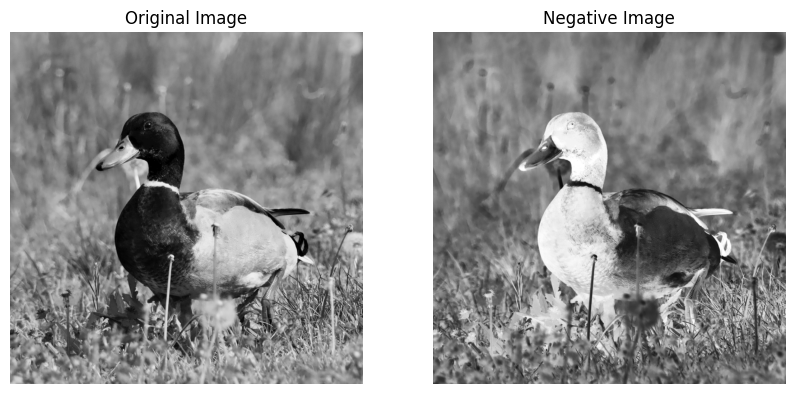

In [4]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Negative Image")
plt.imshow(negative, cmap="gray")
plt.axis("off")

plt.show()

### 1.1.2 Log Transformation


Log transformation is a gray-level transformation technique that maps a narrow range of low-intensity (dark) pixel values to a wider range of output values, thereby enhancing the details in darker regions of an image.

$$
s = c \cdot \text{log}(1+r)
$$

Where, <br>
$\qquad r =$ Input pixel intensity <br>
$\qquad s =$ Output pixel intensity <br>
$\qquad c =$ Scaling constant, defined as: <br>

$$
c = \frac{255}{\text{log}(1+r_{max})}
$$

$\qquad r_{max} =$ maximum pixel value in the input image (usually 255)


**Program to implement log transformation**


In [5]:
img_float = np.float32(img)

log_transformed = np.log1p(img_float)
log_transformed = cv2.normalize(log_transformed, None, 0, 255, cv2.NORM_MINMAX)
log_transformed = np.uint8(log_transformed)

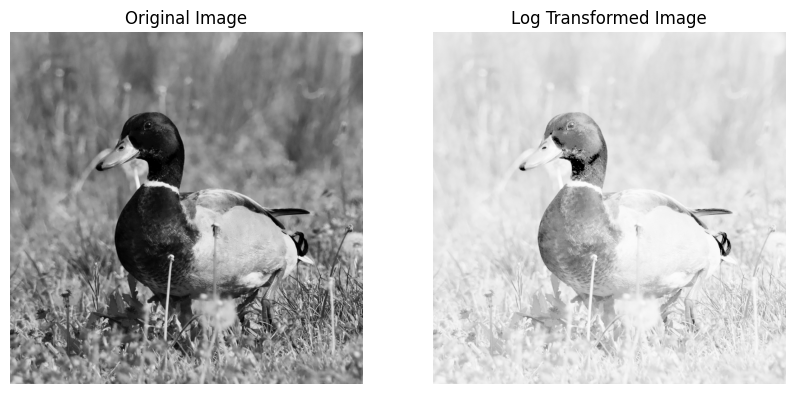

In [6]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Log Transformed Image")
plt.imshow(log_transformed, cmap="gray")
plt.axis("off")

plt.show()

### 1.1.3 Power-Law (Gamma) Transformation


Power-law transformation, also called Gamma Transformation, is used in image processing to enhance an image by modifying its brightness levels using a power function. It is useful for brightness correction, gamma correction and enhancing dark or bright regions.

$$
s = c \cdot r^{\gamma}
$$

Where, <br>
$\qquad r =$ Input pixel intensity <br>
$\qquad s =$ Output pixel intensity <br>
$\qquad c =$ Constant (usually 1) <br>
$\qquad \gamma =$ Gamma value <br>

Effect of Gamma Value <br>
$\qquad$ When $\gamma < 1$ then image becomes brighter <br>
$\qquad$ When $\gamma > 1$ then image becomes darker <br>
$\qquad$ When $\gamma = 1$ then no change <br>


**Program to gamma transformation**


In [7]:
img_float = img / 255.0

gamma = 0.5

gamma_corrected = np.power(img_float, gamma)
gamma_corrected = np.uint8(gamma_corrected * 255)

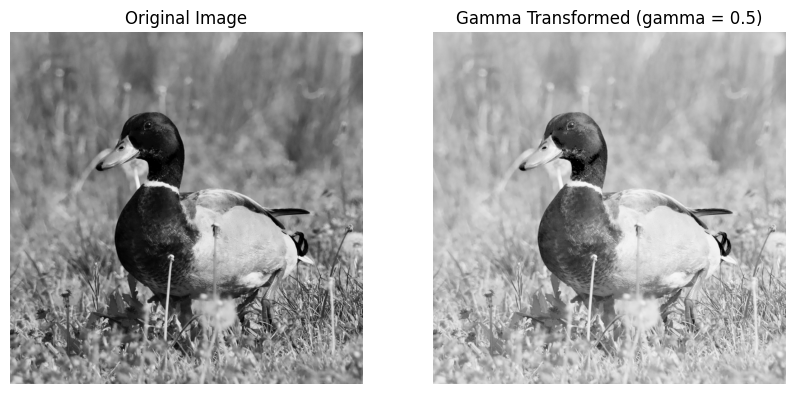

In [8]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title(f"Gamma Transformed (gamma = {gamma})")
plt.imshow(gamma_corrected, cmap="gray")
plt.axis("off")

plt.show()

### 1.1.4 Contrast Stretching


Contrast Stretching is an image enhancement technique used to improve the contrast of an image by stretching the range of intensity values. It expands the narrow intensity range of an image to the full display range (usually 0 to 255). This makes dark regions darker and bright regions brighter, improving visibility. The equation for contrast stretching is given as,

$$
s = \frac{(r-r_{min})(L-1)}{r_{max}-r_{min}}
$$

Where, <br>
$\qquad r =$ Input pixel intensity <br>
$\qquad s =$ Output pixel intensity <br>
$\qquad r_{min} =$ Minimum intensity in input image <br>
$\qquad r_{max} =$ Maximum intensity in input image <br>


**Program to implement contrast stretching**


In [9]:
r_min = np.min(img)
r_max = np.max(img)

stretched = ((img - r_min) / (r_max - r_min)) * 255
stretched = np.uint8(stretched)

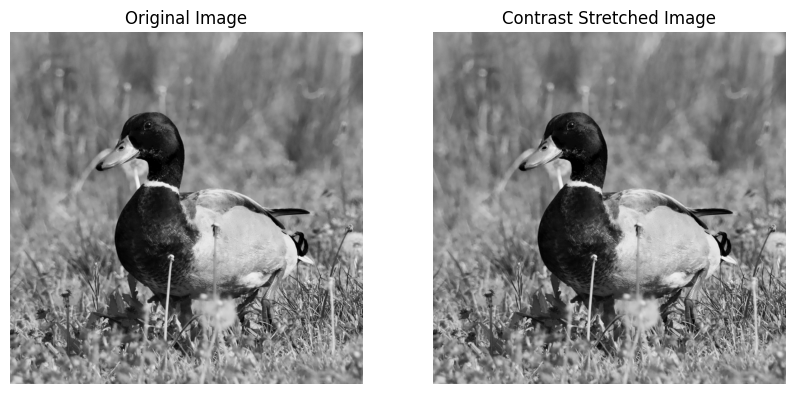

In [10]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Contrast Stretched Image")
plt.imshow(stretched, cmap="gray")
plt.axis("off")

plt.show()

### 1.1.5 Thresholding


Thresholding is a simple yet powerful segmentation technique that converts a grayscale image into a binary image (black and white) by comparing each pixel's intensity to a fixed value called the threshold value ($T$). Mathematically, it is defined as,

$$
s = \begin{cases} 255, & \text{if } r \geq T \\ 0, & \text{if } r < T \end{cases}
$$

Where, <br>
$\qquad r =$ Input pixel intensity <br>
$\qquad s =$ Output pixel intensity <br>
$\qquad T =$ Threshold value <br>


In [ ]:
threshold_value = 80

_, threshold_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

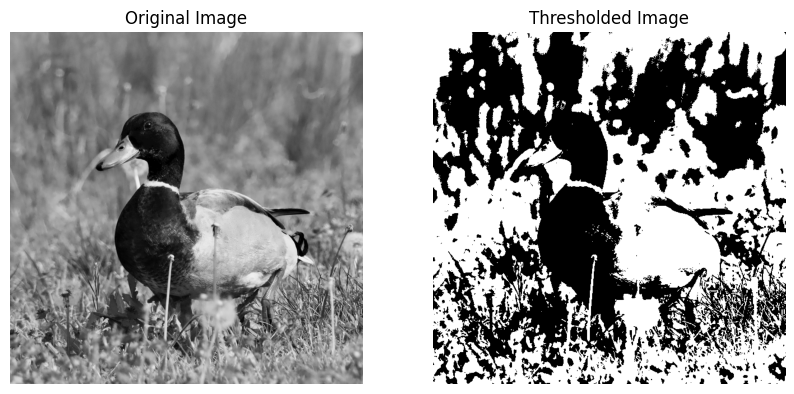

In [12]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Thresholded Image")
plt.imshow(threshold_img, cmap="gray")
plt.axis("off")

plt.show()